In [1]:
%pip uninstall torch torchvision torchaudio -y


Found existing installation: torch 2.0.1+cu117
Uninstalling torch-2.0.1+cu117:
  Successfully uninstalled torch-2.0.1+cu117
Found existing installation: torchvision 0.15.2+cu117
Uninstalling torchvision-0.15.2+cu117:
  Successfully uninstalled torchvision-0.15.2+cu117
Found existing installation: torchaudio 2.0.2+cu117
Uninstalling torchaudio-2.0.2+cu117:
  Successfully uninstalled torchaudio-2.0.2+cu117
Note: you may need to restart the kernel to use updated packages.


# Prerequisities
In this section we install all necerssary libraries and and import them. Additionally, we also set up the config to use for the training later on. 

## Installation Block

In [2]:
#Install block based on HuggingFace
%pip install datasets
%pip install diffusers
%pip install Pillow
%pip install PIL
%pip install torch==2.0.1+cu117 torchvision==0.15.2+cu117 torchaudio==2.0.2+cu117 --extra-index-url https://download.pytorch.org/whl/cu117 --no-cache-dir --user
%pip uninstall numpy
%pip install numpy==1.26.4
%pip install accelerate
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Block

In [3]:
import torch
from datasets import load_dataset
import torchvision
import PIL
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup


c:\Users\nceck\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Training Configuration 

In [4]:
from dataclasses import dataclass


@dataclass
class TrainingConfig:
    image_size = 32  # the generated image resolution - 28px to fit the original images
    train_batch_size = 64
    eval_batch_size = 64  # how many images to sample during evaluation
    num_epochs = 19
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 500
    save_image_epochs = 1
    #save_model_epochs = 1
    mixed_precision='fp16' # this 
    device_placement=True
    output_dir = "ddpm-mnist-output"  # the model name locally and on the HF Hub
    overwrite_output_dir = True  # overwrite the old model when re-running the notebook
    seed = 0
    num_inference_steps = 500


config = TrainingConfig()

# Data 

In [5]:
# Load the data from HuggingFace
ds = load_dataset("ylecun/mnist")
train_dataset = load_dataset("ylecun/mnist", split="train[:100%]")

## Preprocessing


In [6]:
# General preprocessing for later randomisation of the dataset 
preprocess = transforms.Compose(
    [   
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform_to_grayscale(examples):
    images = [preprocess(image.convert("L")) for image in examples["image"]]
    return {"images": images}


train_dataset.set_transform(transform_to_grayscale) # Transformation to grayscale

In [7]:
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=config.train_batch_size, shuffle=True)

## Model Components

In [8]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=config.image_size,  # the target image resolution
    in_channels=1,  # the number of input channels, 3 for RGB images; here: 1 to fit greyscale images
    out_channels=1,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(32,64, 128, 128),  # the number of output channels for each UNet block
    #block_out_channels=(128, 128, 256, 256, 512, 512), 
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",  # a regular ResNet upsampling block
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",
    ),
)

In [9]:
sample_image = train_dataset[0]["images"].unsqueeze(0)

# Check if the shape of input img and model output match
print("Input shape:", sample_image.shape)
print("Output shape:", model(sample_image, timestep=0).sample.shape)

Input shape: torch.Size([1, 1, 32, 32])
Output shape: torch.Size([1, 1, 32, 32])


In [10]:
# Initialise all necerssary model components: noise schedular

noise_scheduler = DDPMScheduler(num_train_timesteps=500)
noise = torch.randn(sample_image.shape) #TODO: Removal?
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)



# Training

In [11]:
from diffusers import DDPMPipeline
import math
import os


def make_grid(images, rows, cols):
    w, h = images[0].size
    grid = Image.new("RGB", size=(cols * w, rows * h))
    for i, image in enumerate(images):
        grid.paste(image, box=(i % cols * w, i // cols * h))
    return grid


def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.manual_seed(config.seed),
        num_inference_steps=500
    ).images

    # Make a grid out of the images
    image_grid = make_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [12]:
import torch.nn.functional as F
timesteps = torch.LongTensor([50])
noisy_image = noise_scheduler.add_noise(sample_image, noise, timesteps) 
noise_pred = model(noisy_image, timesteps).sample
loss = F.mse_loss(noise_pred, noise)

In [13]:
from accelerate import Accelerator
from huggingface_hub import HfFolder, Repository, whoami
from tqdm.auto import tqdm
from pathlib import Path
import os

accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        #log_with="tensorboard",
        #logging_dir=os.path.join(config.output_dir, "logs"),
    )
def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    
    if accelerator.is_main_process:
        os.makedirs(config.output_dir, exist_ok=True)
        accelerator.init_trackers("train_example")

    # Prepare everything
    # There is no specific order to remember, you just need to unpack the
    # objects in the same order you gave them to the prepare method.
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    # Now you train the model
    for epoch in range(1):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            clean_images = batch["images"]
            # Sample noise to add to the images
            noise = torch.randn(clean_images.shape).to(clean_images.device)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device
            ).long()
            

            # Add noise to the clean images according to the noise magnitude at each timestep
            # (this is the forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0] # predict the noise that was added to the image
                loss = F.mse_loss(noise_pred, noise) # loss function (prediction vs actual noise)
                accelerator.backward(loss) #backpropagation 

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            if global_step % 10 == 0:
                progress_bar.update(10)
                progress_bar.set_postfix(**logs)
            #accelerator.log(logs, step=global_step)
            global_step += 1

        # After each epoch you optionally sample some demo images with evaluate() and save the model
        if accelerator.is_main_process:
            pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)

        if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
            evaluate(config, epoch, pipeline)
                #pipeline.save_pretrained(config.output_dir)

In [14]:
from accelerate import notebook_launcher

args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)

notebook_launcher(train_loop, args, num_processes=1)

Launching training on one GPU.


100%|██████████| 500/500 [01:08<00:00,  7.27it/s]lr=9.98e-5, step=930]                       
Epoch 0: : 940it [05:44,  2.73it/s, loss=0.0337, lr=9.98e-5, step=930]


# Visualisation

In this section we visualise the results from the previous training. Following the structure from the previous code, we first visualise examplatory the forward diffusion process and then later on the backward diffusion process. 

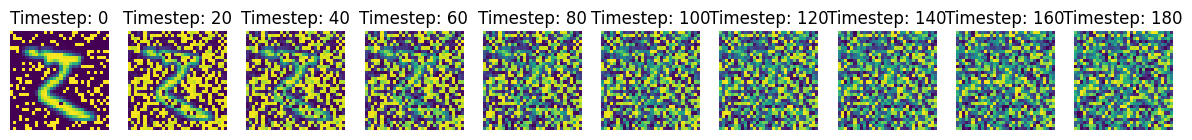

In [15]:
# Visualise the forward diffusion process 


#Image.fromarray(((noisy_image.permute(0, 2, 3, 1) + 1.0) * 127.5).type(torch.uint8).numpy()[0])

noisy_image_np = ((noisy_image.permute(0,2,3,1) + 1.0) * 127.5).type(torch.uint8).numpy()
first_noisy_image = noisy_image_np[0]

# Check if the image has a single channel (grayscale) and reshape if necessary
if first_noisy_image.shape[2] == 1:
    first_noisy_image = first_noisy_image[:, :, 0]

# Convert the numpy array to a PIL image
noisy_pil_image = Image.fromarray(first_noisy_image)



# Convert the PIL image to grayscale (if not already in grayscale)
grayscale_image = noisy_pil_image.convert("L")
timesteps_to_visualize = [0, 20, 40, 60,  80, 100,  120,  140, 160, 180]
# Display or save the grayscale image
#grayscale_image.show() 
plt.figure(figsize=(15,3))

for i, timestep in enumerate(timesteps_to_visualize):
    timesteps = torch.LongTensor([timestep])
    noisy_image = noise_scheduler.add_noise(sample_image, noise, timesteps)
    
    # Convert the noisy image tensor to a numpy array suitable for PIL
    noisy_image_np = ((noisy_image.permute(0, 2, 3, 1) + 1.0) * 127.5).type(torch.uint8).numpy()
    first_noisy_image = noisy_image_np[0]
    
    # Check if the image has a single channel (grayscale) and reshape if necessary
    if first_noisy_image.shape[2] == 1:
        first_noisy_image = first_noisy_image[:, :, 0]
    
    # Convert the numpy array to a PIL image
    noisy_pil_image = Image.fromarray(first_noisy_image).convert("L")
    
    plt.subplot(1, len(timesteps_to_visualize), i + 1)
    plt.imshow(noisy_pil_image)
    plt.title(f"Timestep: {timestep}")
    plt.axis("off")
plt.show()

Visualise Final Batch Results

100%|██████████| 240/240 [00:15<00:00, 15.89it/s]


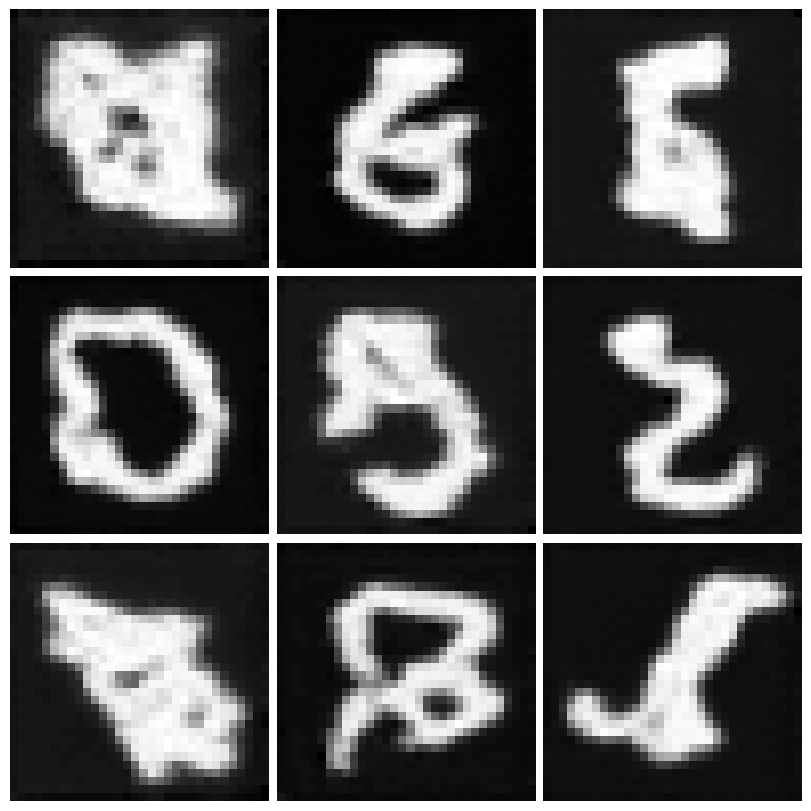

In [21]:
pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)
timesteps_to_visualize = [1,3, 5, 6, 20, 40, 60,  80, 100,  120,  140, 160, 180, 200, 220, 240]
images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.manual_seed(config.seed),
        num_inference_steps=timestep
    ).images

fig, ax = plt.subplots(3, 3, figsize=(8, 8),  layout='constrained')

for i in range(9):
    ax[i // 3, i % 3].imshow(images[i], cmap='Greys_r')
    ax[i // 3, i % 3].axis('off')

plt.show()

100%|██████████| 240/240 [00:30<00:00,  7.76it/s]


<Figure size 1500x300 with 0 Axes>

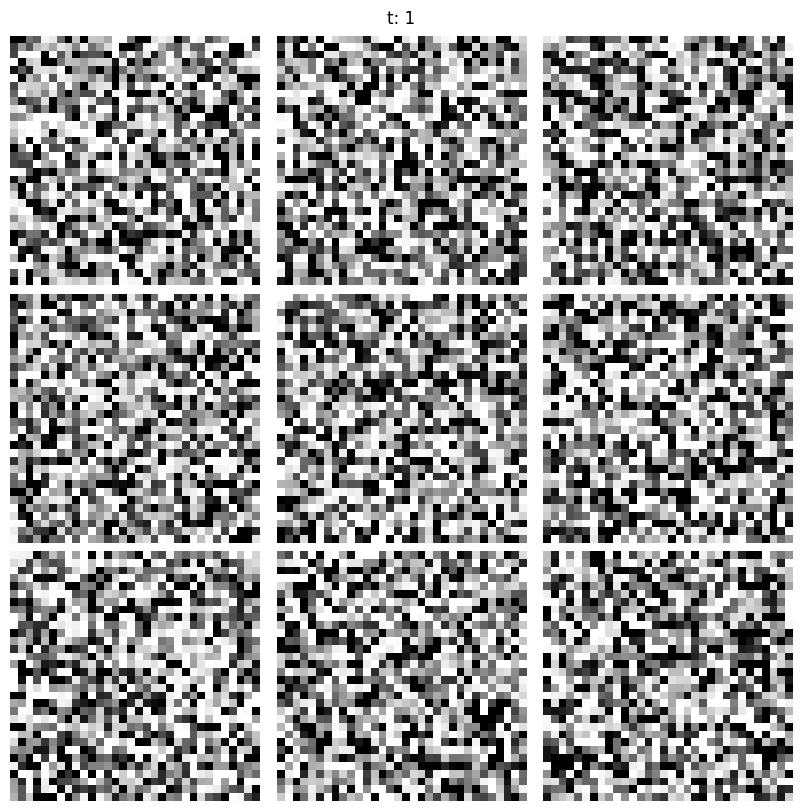

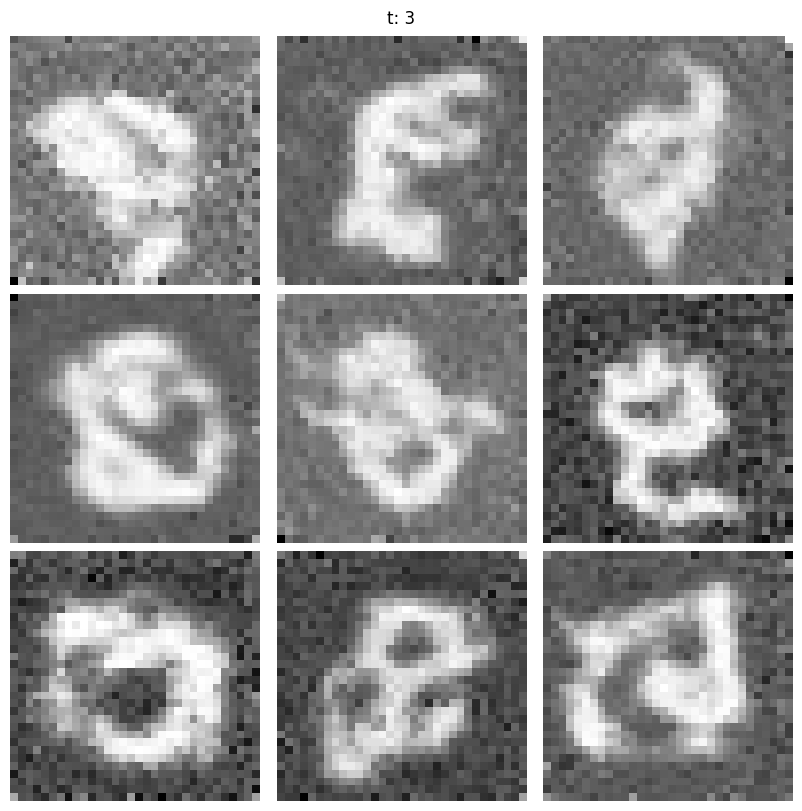

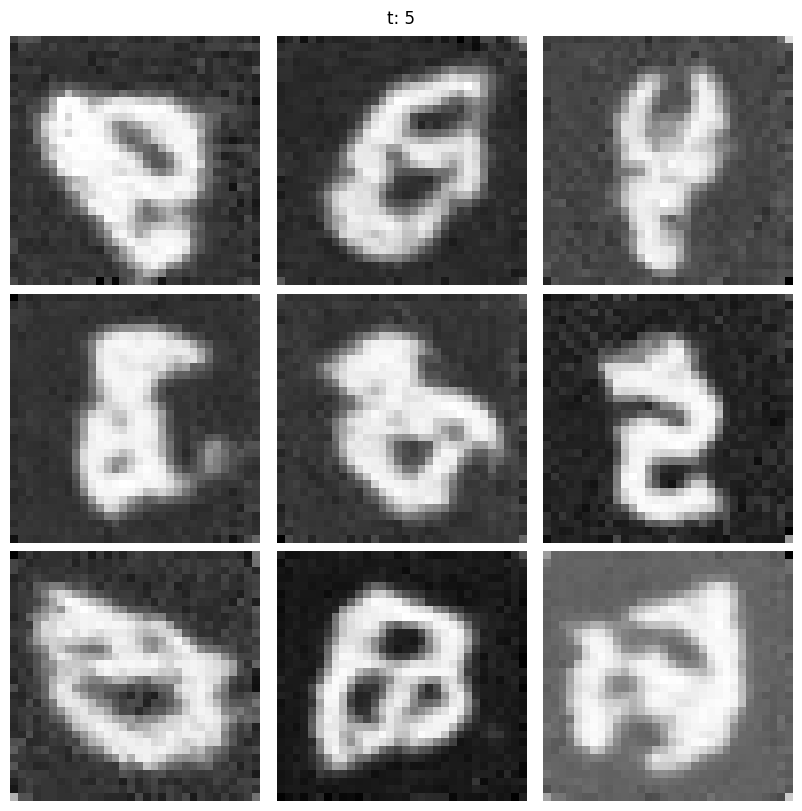

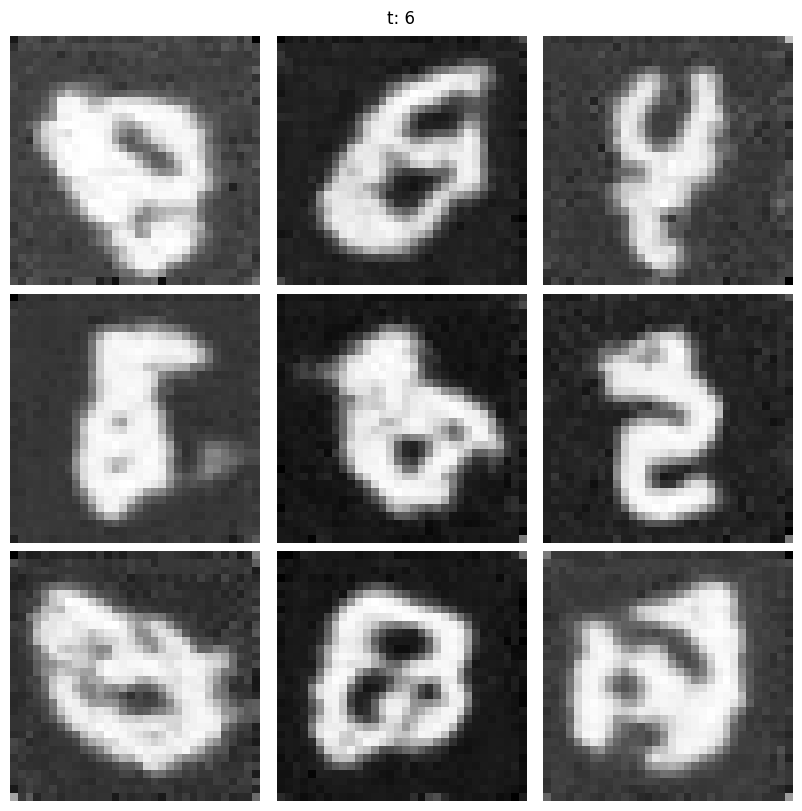

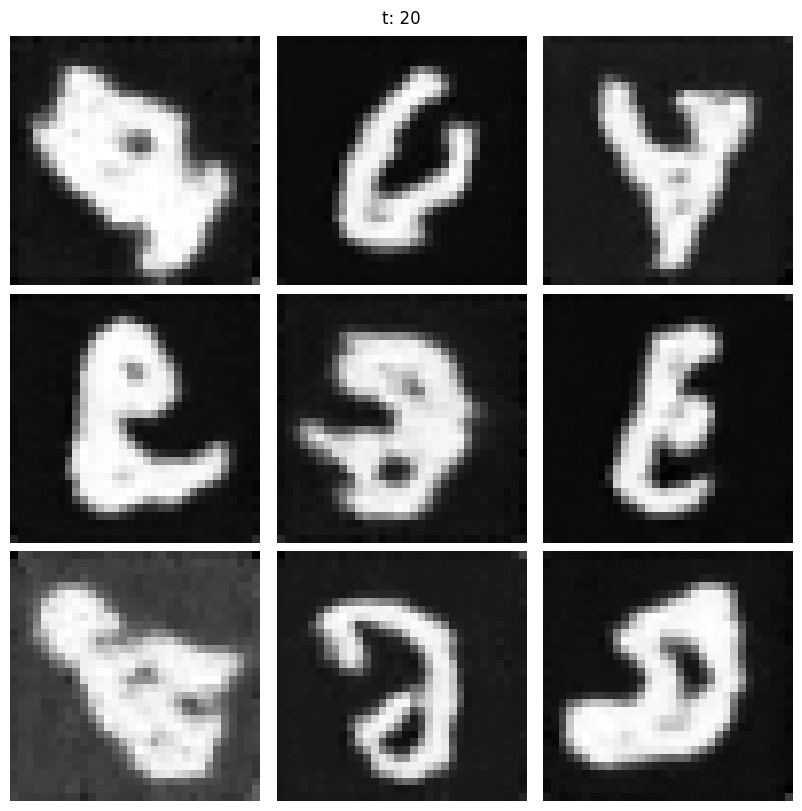

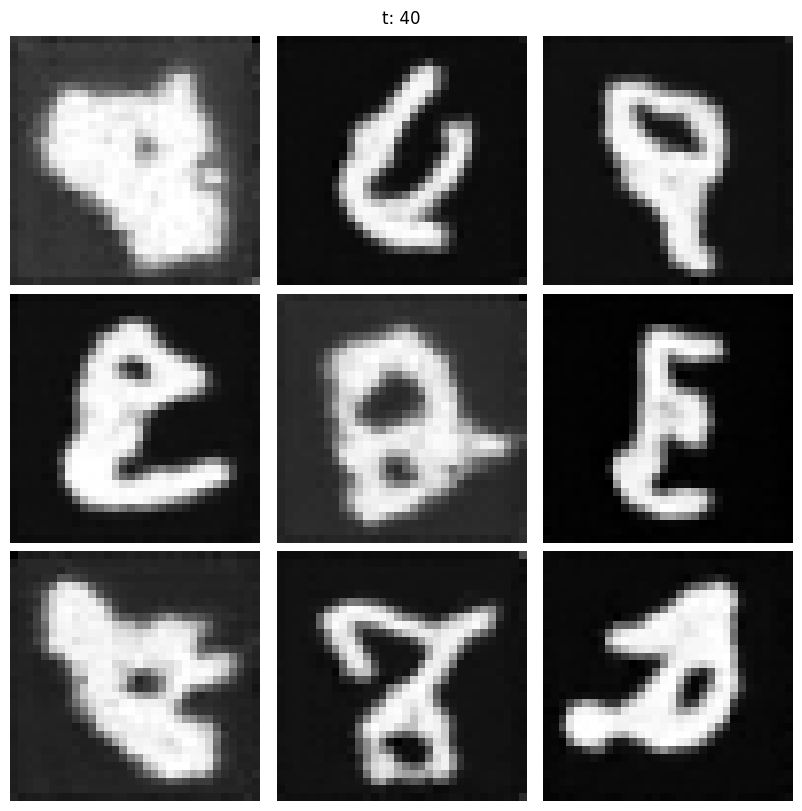

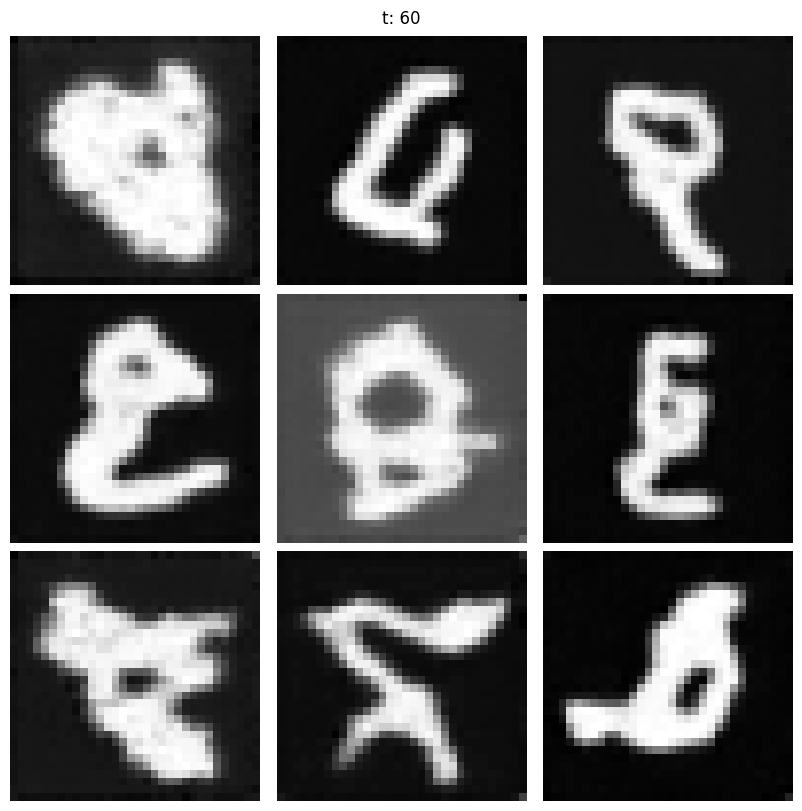

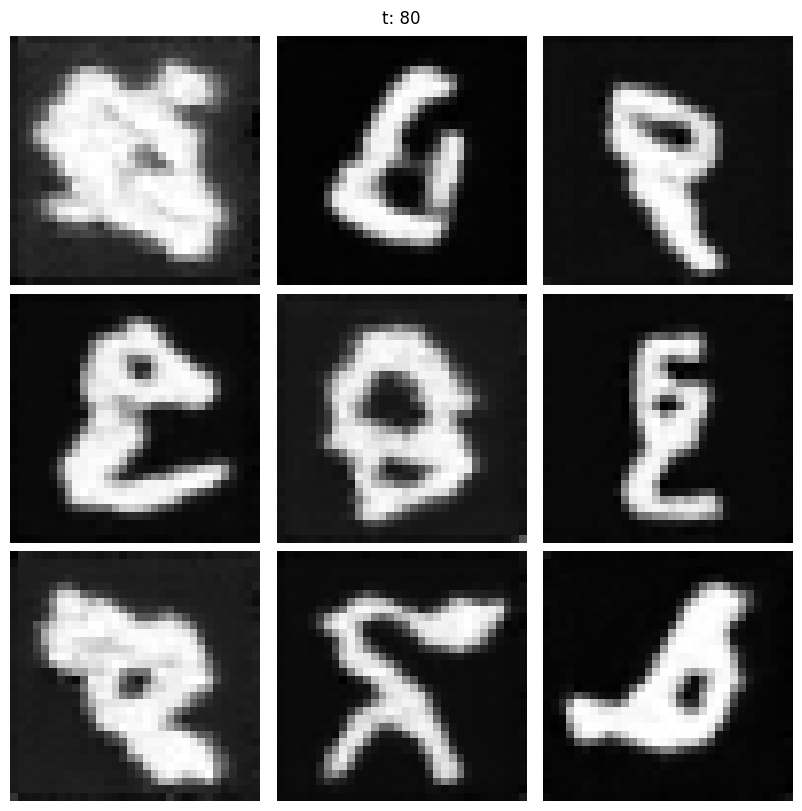

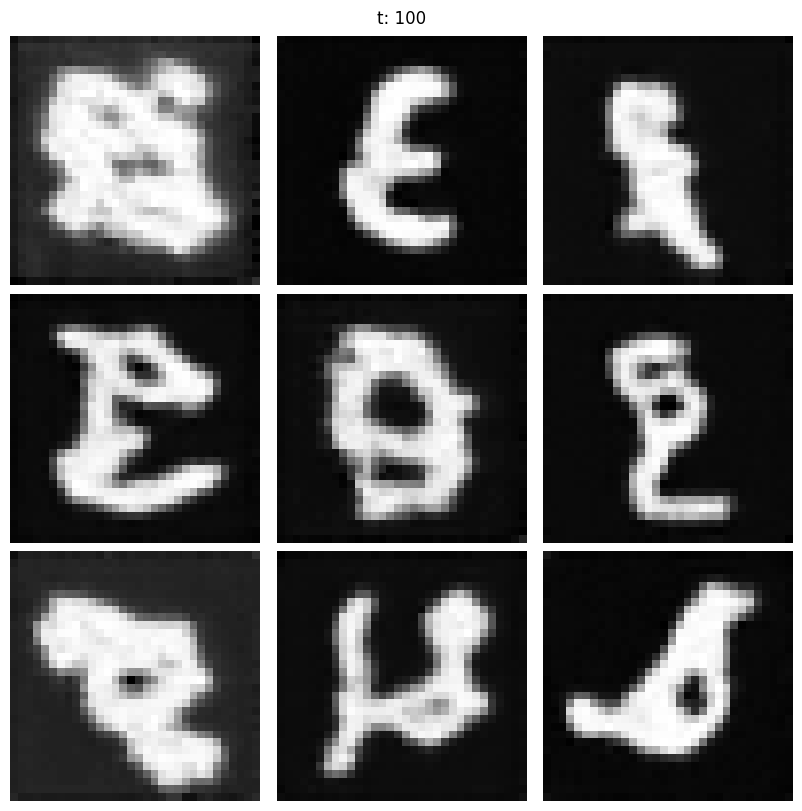

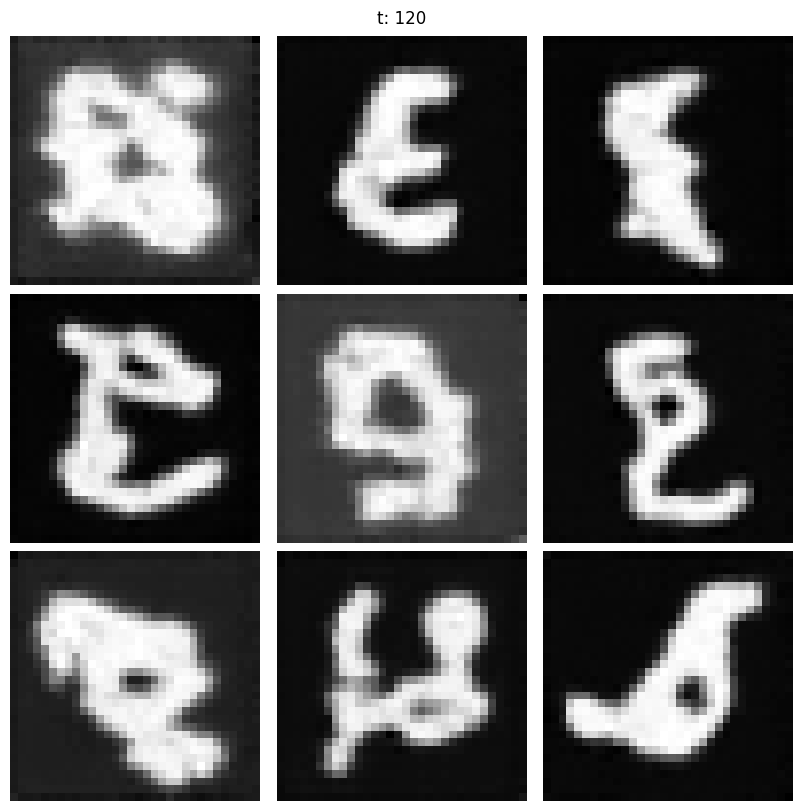

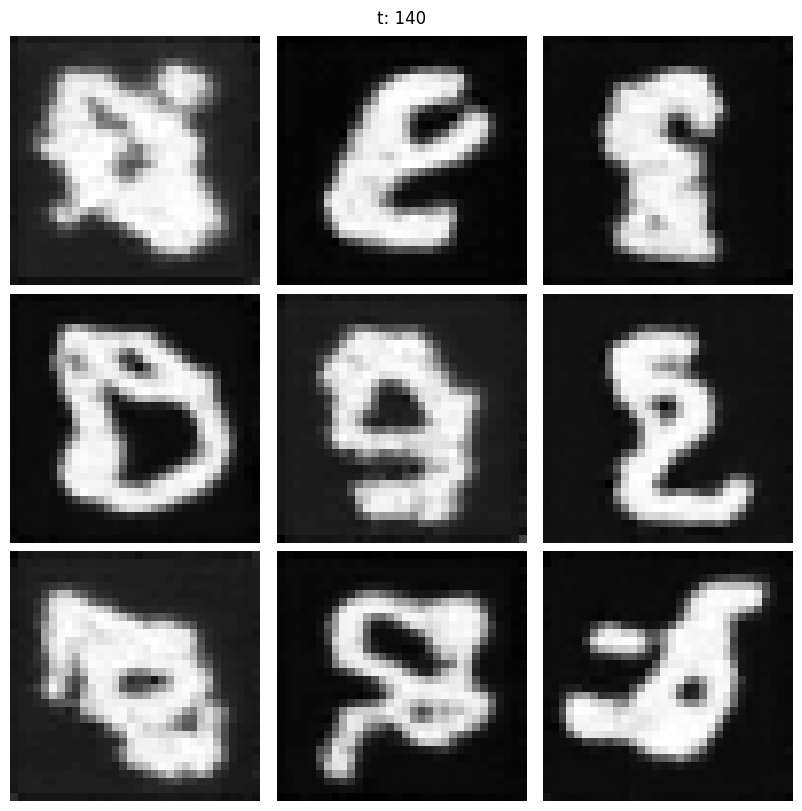

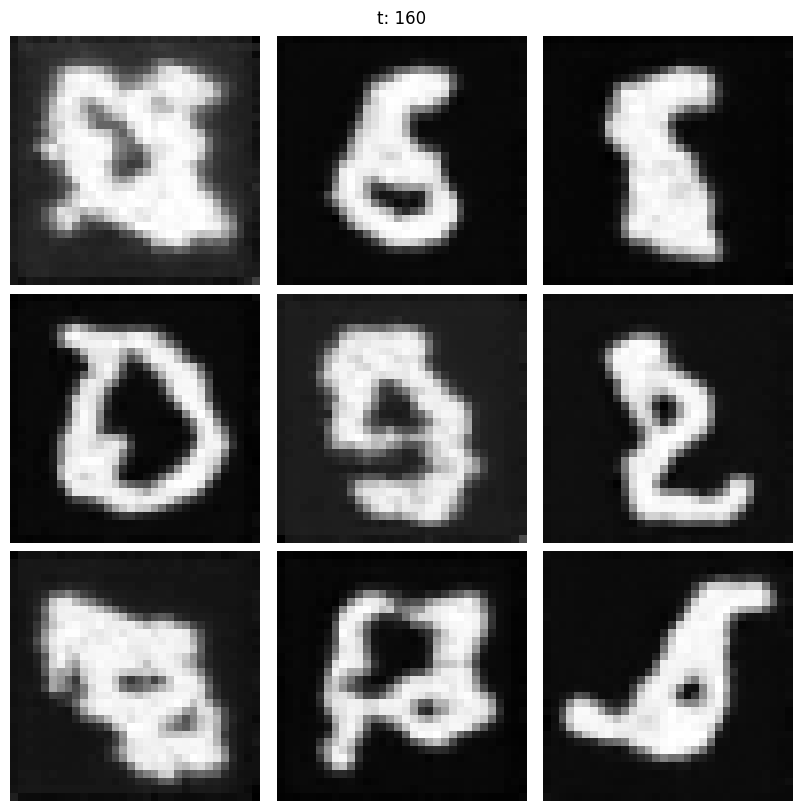

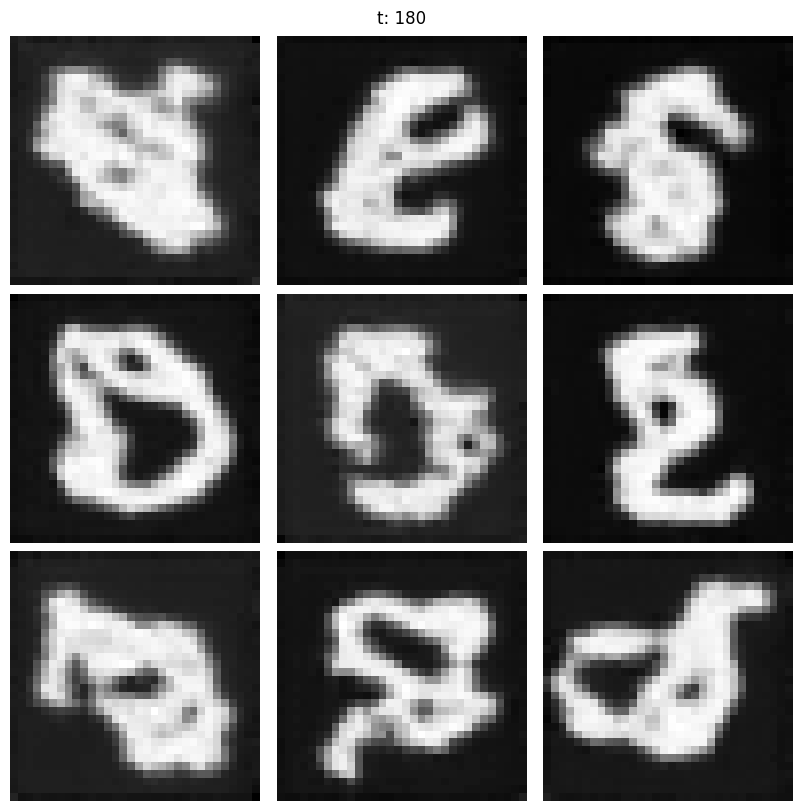

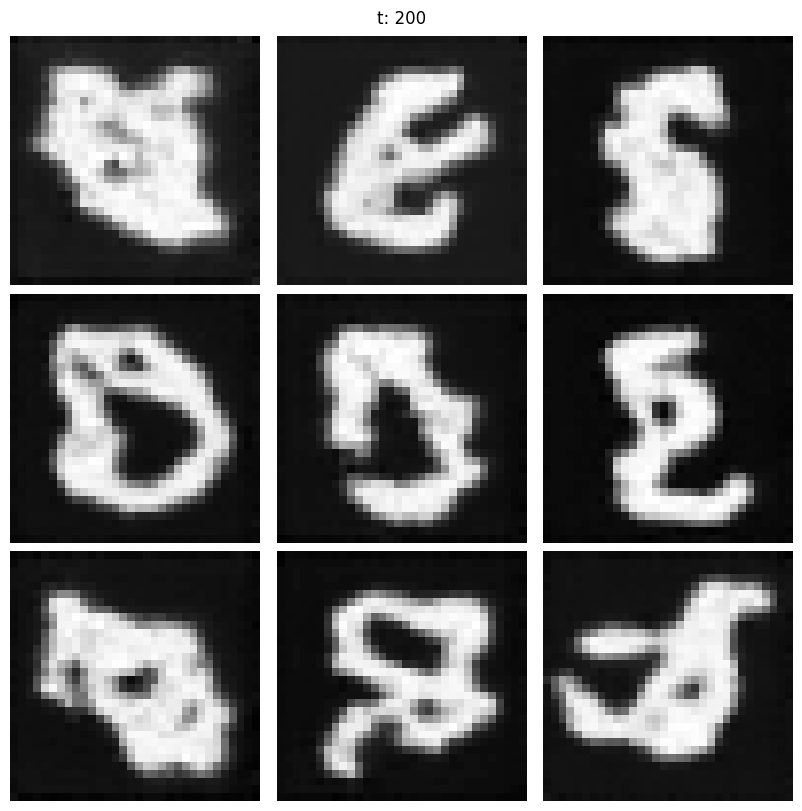

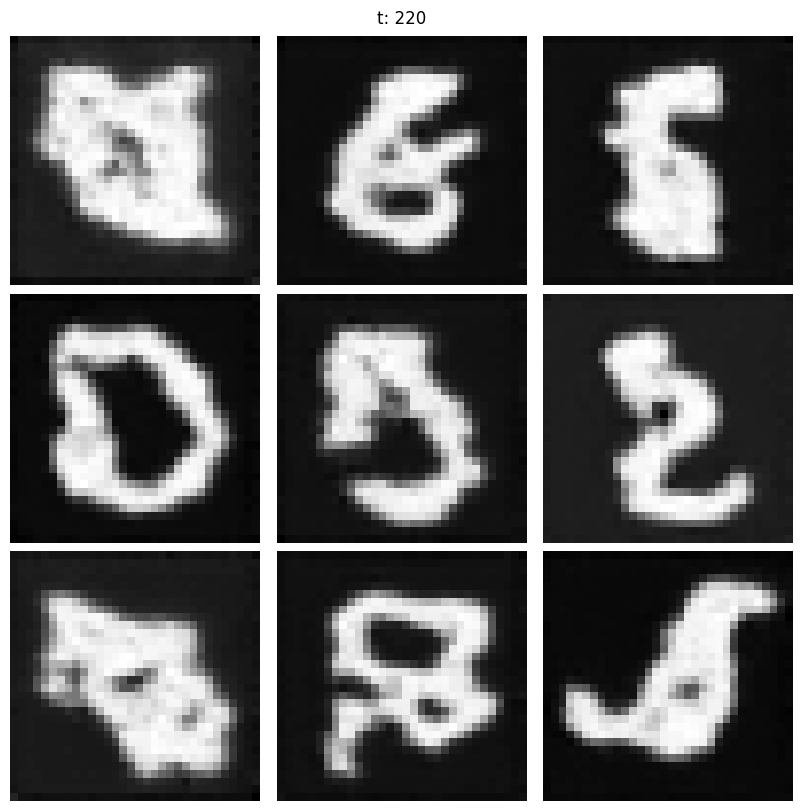

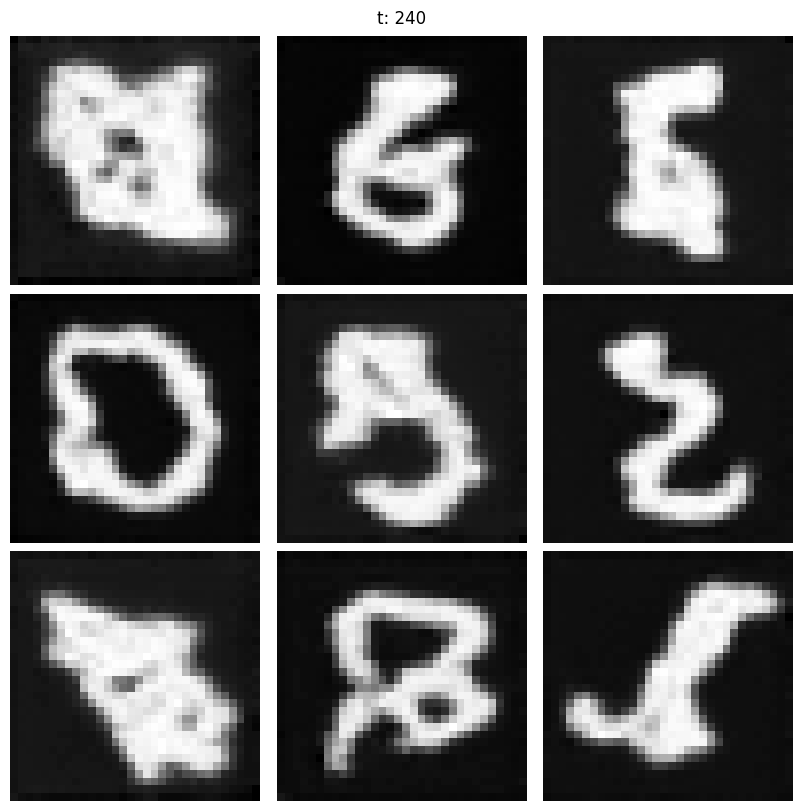

In [22]:
timesteps_to_visualize = [1,3, 5, 6, 20, 40, 60,  80, 100,  120,  140, 160, 180, 200, 220, 240]
pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)

plt.figure(figsize=(15,3))
for i, timestep in enumerate(timesteps_to_visualize): #TODO adjust to one img
    
    
    images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.manual_seed(config.seed),
        num_inference_steps=timestep
    ).images
    fig, ax = plt.subplots(3, 3, figsize=(8, 8),  layout='constrained')
    fig.suptitle(f"t: {timestep}")
    for i in range(9):
      ax[i // 3, i % 3].imshow(images[i], cmap='Greys_r')
      ax[i // 3, i % 3].axis('off') 
    
plt.show()

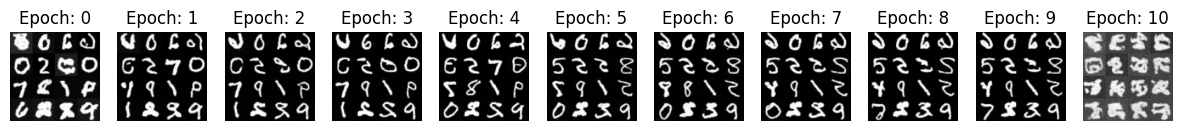

In [ ]:
# Visualise the results of the training process per iteration
import glob
#load images from result repository
sample_images = sorted(glob.glob(f"{config.output_dir}/samples/*.png"))



plt.figure(figsize=(15,3))

for i, timestep in enumerate(sample_images):
    image = Image.open(sample_images[i])
    plt.subplot(1, len(sample_images), i + 1)
    plt.imshow(image)
    plt.title(f"Epoch: {i}")
    plt.axis("off")
